In [55]:
import pandas as pd
import numpy as np
import pandas as pd 

In [56]:
df=pd.read_csv('/Users/priyanshugupta/Desktop/scikit learn/CAR DETAILS FROM CAR DEKHO.csv',usecols=['name','seller_type','transmission','owner','fuel'])
df.head()

,name,fuel,seller_type,transmission,owner
0,Maruti 800 AC,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,Diesel,Individual,Manual,Second Owner


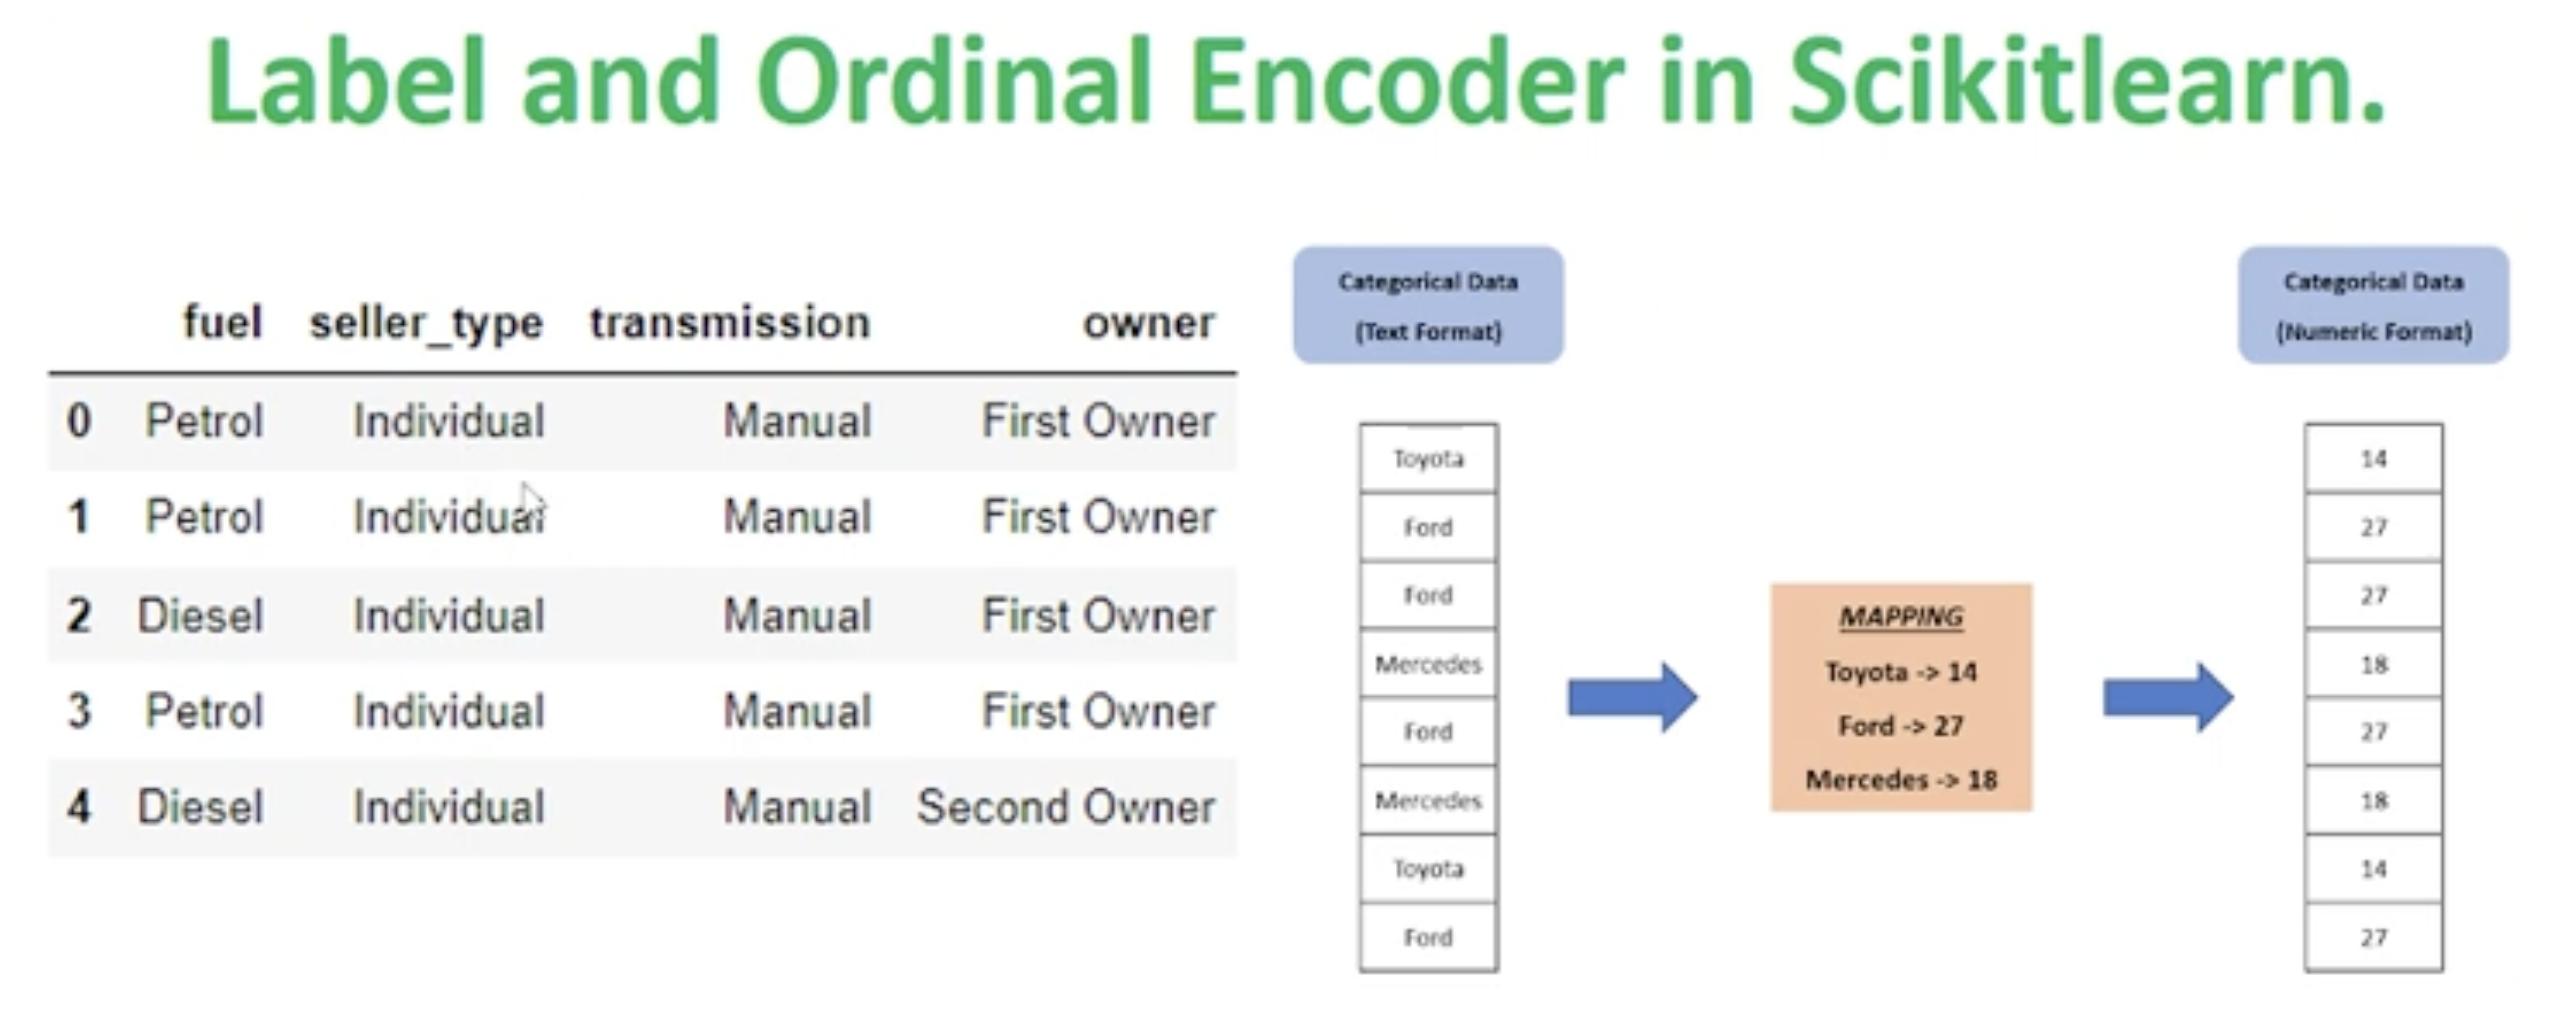

## types of categorical data -> nominal, ordinal data

nominal -> there is no order ex-Orange,Red,Yellow

ordinal -> there is order ex-Small,medium,large,extra large

In [57]:
df.drop('name',axis=1,inplace=True)

In [58]:
df['transmission'].value_counts()

transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

In [59]:
df['transmission']=df['transmission'].map({'Manual':0,'Automatic':1})


In [60]:
df['seller_type'].value_counts()

seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64

In [61]:
df['seller_type']=df['seller_type'].map({'Individual':0,'Dealer':1,'Trustmark Dealer':2})
df.sample(5)

,fuel,seller_type,transmission,owner
4184,Diesel,1,0,First Owner
2958,Petrol,0,0,Second Owner
893,Petrol,0,0,Second Owner
3226,Diesel,0,0,Second Owner
1476,Petrol,1,0,First Owner


In [62]:
df['owner'].value_counts()

owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64

In [63]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop('fuel',axis=1),df['fuel'],test_size=0.2,random_state=34)

## Label Encoding and One hot Encoding

In [64]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder
le=LabelEncoder()
oe=OrdinalEncoder()
ohe=OneHotEncoder()
## we use labelEncoder for predicted/target variable 
## we use OrdinalEncoder when there is some order involved like group A,group B 

In [65]:
y_test_scaled=le.fit_transform(y_test)
y_train_scaled=le.fit_transform(y_train)

In [66]:
df['fuel'].value_counts()

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

In [67]:
y_train_scaled

array([4, 1, 4, ..., 4, 1, 4], shape=(3472,))

In [68]:
X_train

,seller_type,transmission,owner
2871,0,0,Second Owner
169,0,0,Third Owner
2181,2,0,First Owner
3955,0,0,First Owner
1751,1,0,First Owner
...,...,...,...
324,1,0,First Owner
3157,1,1,First Owner
3830,0,0,Fourth & Above Owner
2538,1,0,First Owner


In [69]:
X_train_scaled=oe.fit_transform(X_train)
X_test_scaled=oe.transform(X_test)

In [70]:
X_train_scaled

array([[0., 0., 2.],
       [0., 0., 4.],
       [2., 0., 0.],
       ...,
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 0.]], shape=(3472, 3))

## For nominal data we use OneHotEncoding  ( when there is no order)


no of columns it creates=no of unique values in that column

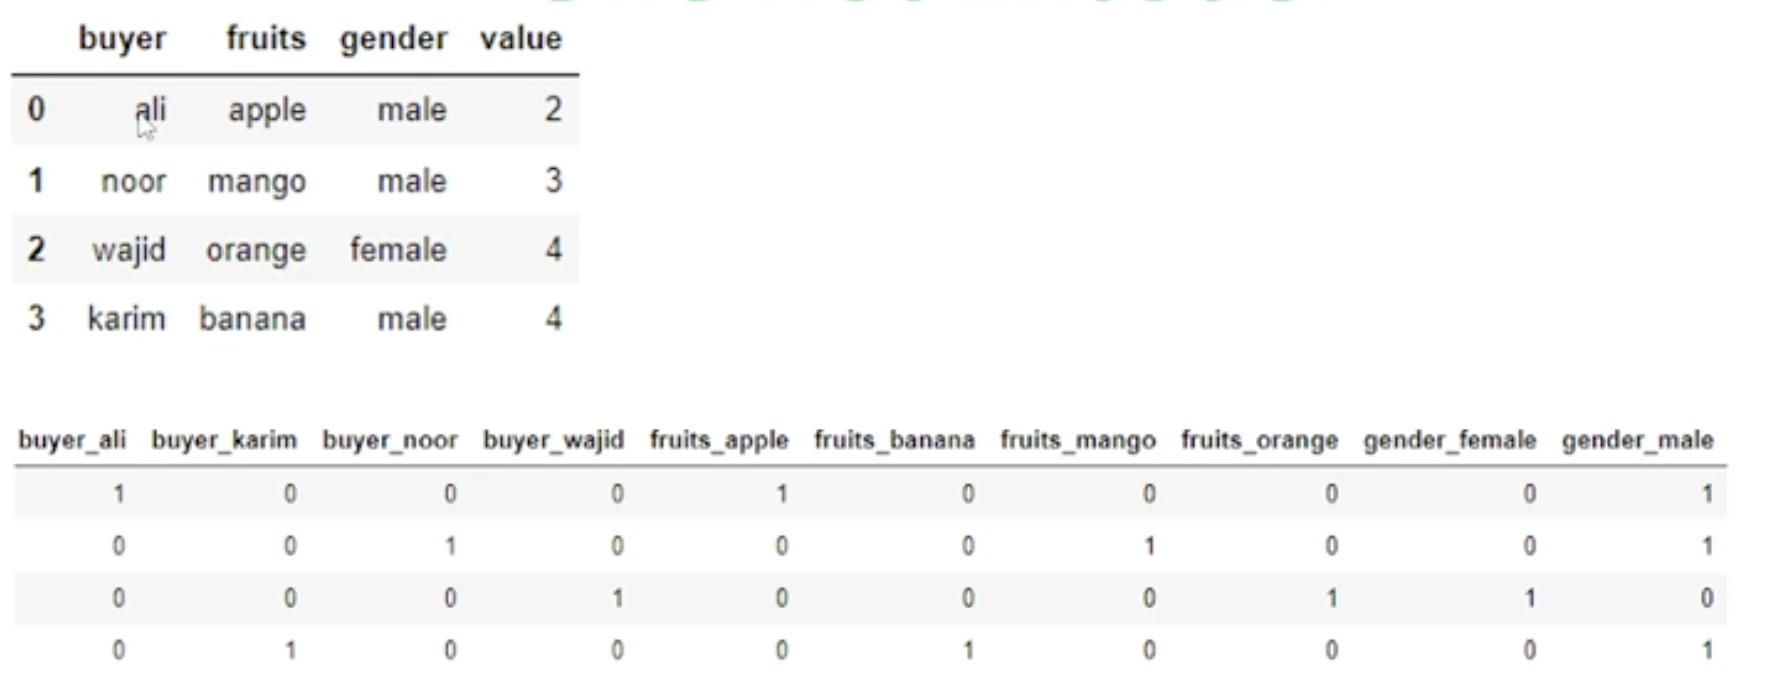

In [76]:
df.head(5)

,fuel,seller_type,transmission,owner
0,Petrol,0,0,First Owner
1,Petrol,0,0,First Owner
2,Diesel,0,0,First Owner
3,Petrol,0,0,First Owner
4,Diesel,0,0,Second Owner


In [77]:
## using pandas

pd.get_dummies(data=df,columns=['fuel','owner'])


,seller_type,transmission,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,0,0,False,False,False,False,True,True,False,False,False,False
1,0,0,False,False,False,False,True,True,False,False,False,False
2,0,0,False,True,False,False,False,True,False,False,False,False
3,0,0,False,False,False,False,True,True,False,False,False,False
4,0,0,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4335,0,0,False,True,False,False,False,False,False,True,False,False
4336,0,0,False,True,False,False,False,False,False,True,False,False
4337,0,0,False,False,False,False,True,False,False,True,False,False
4338,0,0,False,True,False,False,False,True,False,False,False,False


In [78]:
pd.get_dummies(data=df,columns=['fuel','owner'],dtype='int')


,seller_type,transmission,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,0,0,0,0,0,0,1,1,0,0,0,0
1,0,0,0,0,0,0,1,1,0,0,0,0
2,0,0,0,1,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,1,1,0,0,0,0
4,0,0,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4335,0,0,0,1,0,0,0,0,0,1,0,0
4336,0,0,0,1,0,0,0,0,0,1,0,0
4337,0,0,0,0,0,0,1,0,0,1,0,0
4338,0,0,0,1,0,0,0,1,0,0,0,0


In [ ]:
## for a col with only two values we remove the first column bcz second col already tells about it 
## if 1st col is 0 then second col will obviously 1 and vice versa
## pd.get_dummies(data=df,columns=[], drop='first')

,fuel,seller_type,transmission,owner
0,Petrol,0,0,First Owner
1,Petrol,0,0,First Owner
2,Diesel,0,0,First Owner
3,Petrol,0,0,First Owner
4,Diesel,0,0,Second Owner
...,...,...,...,...
4335,Diesel,0,0,Second Owner
4336,Diesel,0,0,Second Owner
4337,Petrol,0,0,Second Owner
4338,Diesel,0,0,First Owner


## With Sklearn

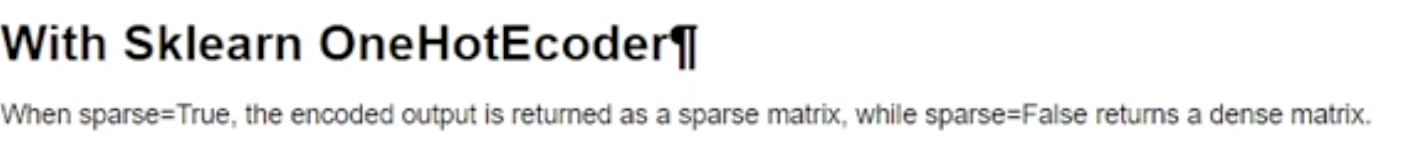

In [85]:
df1=pd.read_csv('/Users/priyanshugupta/Desktop/scikit learn/Social_Network_Ads.csv')
df1.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
pd.get_dummies(data=df1,columns=['Gender'],dtype=int,drop_first='first')
## if suppose we have two features then we can drop one feature and get only other feature

,User ID,Age,EstimatedSalary,Purchased,Gender_Male
0,15624510,19,19000,0,1
1,15810944,35,20000,0,1
2,15668575,26,43000,0,0
3,15603246,27,57000,0,0
4,15804002,19,76000,0,1
...,...,...,...,...,...
395,15691863,46,41000,1,0
396,15706071,51,23000,1,1
397,15654296,50,20000,1,0
398,15755018,36,33000,0,1


In [88]:
from sklearn.preprocessing import OneHotEncoder

ohe=OneHotEncoder(drop='first',dtype=int)
df_trf=ohe.fit_transform(df1[['Gender']])
df_trf

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 196 stored elements and shape (400, 1)>

In [ ]:
ohe=OneHotEncoder(drop='first',dtype=int,sparse_output=False)
df_trf=ohe.fit_transform(df[['fuel']])
df_trf

array([[0, 0, 0, 1],
       [0, 0, 0, 1],
       [1, 0, 0, 0],
       ...,
       [0, 0, 0, 1],
       [1, 0, 0, 0],
       [0, 0, 0, 1]], shape=(4340, 4))

In [97]:
ohe.get_feature_names_out()

array(['fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol'],
      dtype=object)

In [101]:
cols=ohe.get_feature_names_out()
pd.DataFrame(data=df_trf,columns=cols)

,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol
0,0,0,0,1
1,0,0,0,1
2,1,0,0,0
3,0,0,0,1
4,1,0,0,0
...,...,...,...,...
4335,1,0,0,0
4336,1,0,0,0
4337,0,0,0,1
4338,1,0,0,0
